<a href="https://colab.research.google.com/github/Maheshwar-Pant/ML_lab/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 4 : Logistic Regression ,Support Vector Classification(SVC) , and Support Vector Regression (SVR)

This lab session focuses on implementing Logistic Regression , Support Vector Classification (SVC) , and Support Vector Regression (SVR) using Pyhton ans Scikit-learn

## Comparison of Machine Learning Models

Let's break down three powerful machine learning algorithms: Logistic Regression, Support Vector Classifiers (SVC), and Support Vector Regressors (SVR).

### 1. Logistic Regression

*   **Type:** A classification algorithm that is fundamentally a linear model.

*   **Purpose:** Its main goal is to predict the probability that a given data point belongs to a certain class. This is commonly used for binary classification (e.g., yes/no, true/false) but can also be extended to multiple classes.

*   **How it Works:** It uses a special S-shaped curve (called the sigmoid or logistic function) to transform a linear combination of features into a probability score. This score, always between 0 and 1, represents the likelihood of the data point belonging to the positive class.

*   **Strengths:**
    *   **Simple and Interpretable:** The coefficients of the model tell you directly how each feature influences the probability of the outcome, making it easy to understand.
    *   **Efficient:** It's generally fast to train and make predictions, even on moderately sized datasets.
    *   **Linearly Separable Data:** Works very well when the different classes can be clearly separated by a straight line or a flat plane in higher dimensions.

*   **Limitations:**
    *   **Assumes Linearity:** It struggles when the relationship between features and the outcome is complex or non-linear.
    *   **Sensitive to Outliers:** Extreme values in the data can disproportionately affect the model's performance.
    *   **Feature Engineering:** Often requires careful preparation and transformation of features to perform optimally.

### 2. Support Vector Classifier (SVC)

*   **Type:** A versatile classification algorithm known for its kernel-based approach, allowing it to handle both linear and non-linear data.

*   **Purpose:** It aims to find the 'best' possible boundary (hyperplane) that separates different classes in your data. This boundary is chosen to maximize the margin (the distance) between the closest data points of different classes, known as support vectors.

*   **How it Works:**
    *   **Linear Kernel:** When classes can be separated by a straight line (or flat plane), it finds the optimal linear boundary.
    *   **RBF (Radial Basis Function) Kernel:** For more complex, non-linear relationships, the RBF kernel (or other kernels like polynomial) can transform the data into a higher-dimensional space where a linear separation becomes possible. This creates flexible, curved boundaries in the original feature space.

*   **Strengths:**
    *   **Effective in High Dimensions:** Performs well even when you have many features, making it suitable for complex datasets.
    *   **Handles Non-Linearity:** Excels at separating classes that aren't linearly separable, thanks to its kernel trick.
    *   **Robust to Overfitting:** With proper tuning of regularization parameters (like `C`), it can generalize well to unseen data.

*   **Limitations:**
    *   **Computationally Intensive:** Can be slow and memory-demanding for very large datasets, especially with complex kernels.
    *   **Hyperparameter Tuning:** Requires careful selection and tuning of hyperparameters (e.g., `C`, `gamma`) which can be time-consuming.

### 3. Support Vector Regression (SVR)

*   **Type:** A powerful regression algorithm, also based on the principles of Support Vector Machines and leveraging kernels.

*   **Purpose:** Instead of predicting a class, SVR is designed to predict continuous numerical values (e.g., house prices, temperature).

*   **How it Works:** Unlike traditional regression that tries to minimize the error between predictions and actual values, SVR tries to fit a function that has a maximum allowable error (defined by the epsilon, `ε` parameter) for any data point. It seeks to find the function that best approximates the data while staying within this `ε`-tube around the predictions. It also uses kernels (linear, RBF, polynomial) to handle linear and non-linear relationships in the data.

*   **Strengths:**
    *   **Captures Non-Linear Relationships:** Highly effective at modeling complex, non-linear patterns in data through the use of various kernels.
    *   **Epsilon (ε) Parameter:** The `ε` parameter provides control over the acceptable error margin, allowing you to define how much deviation from the true value is tolerable without incurring a penalty.
    *   **Good Generalization:** Often strikes a good balance between accurately fitting the training data and generalizing well to new, unseen data.

*   **Limitations:**
    *   **Sensitive to Hyperparameters:** Its performance is highly dependent on the correct choice of `C` (regularization), `ε` (error tolerance), and the specific kernel used, which can require extensive tuning.
    *   **Scalability:** Similar to SVC, it can be slower on very large datasets compared to simpler regression models.

##Part A: Logistic Regression

### Dataset :
Use the Breast Cancer dataset available in Scikit-learn

### Task 1 :Load the Dataset


In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
x = data.data
y = data.target

## Task 2 : Explore the Dataset



###1. Display the shape of x and y.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Convert features to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
# Add target column
df['target'] = data.target
print(df.shape)

(569, 31)


### 2.Print the first five rows.

In [ ]:
print(df.head())

   mean radius  mean texture  ...  worst fractal dimension  target
0        17.99         10.38  ...                  0.11890       0
1        20.57         17.77  ...                  0.08902       0
2        19.69         21.25  ...                  0.08758       0
3        11.42         20.38  ...                  0.17300       0
4        20.29         14.34  ...                  0.07678       0

[5 rows x 31 columns]


###3. Identify :Number of samples

In [ ]:
print("Samples:", df.shape[0])

Samples: 569


### Number of features

In [ ]:
print("Features:",df.shape[1]-1 )

Features: 30


### Number of classes

In [ ]:
print("Classes:",df['target'].nunique())

Classes: 2


## Task 3 : Split the Dataset

### Split the data into : 80% training and 20% testing

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
x = data.data
y = data.target

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
print("training set shape(x_train):",x_train.shape)
print("Training labels shape (y_train):", y_train.shape)
print("Testing set shape (x_test):", x_test.shape)
print("Testing labels shape (y_test):", y_test.shape)

training set shape(x_train): (455, 30)
Training labels shape (y_train): (455,)
Testing set shape (x_test): (114, 30)
Testing labels shape (y_test): (114,)


## Task 4: Standardize Features

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)  # Fit on training data
x_test_scaled = scaler.transform(x_test)        # Transform test data

# Display shapes
print("Training set shape:", x_train_scaled.shape)
print("Testing set shape:", x_test_scaled.shape)

# Show first 5 rows of scaled training data
print("First five rows of standardized training data:")
print(x_train_scaled[:5])

Training set shape: (455, 30)
Testing set shape: (114, 30)
First five rows of standardized training data:
[[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.

##Task5: Train Logistics Regression Model

In [ ]:

from sklearn.linear_model import LogisticRegression
# Train Logistic Regression model with default parameters
model = LogisticRegression(max_iter=10000)  # increase iterations to ensure convergence
model.fit(x_train_scaled, y_train)

# Evaluate model
train_score = model.score(x_train_scaled, y_train)
test_score = model.score(x_test_scaled, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9736842105263158


##Task6:Make Predictions

In [ ]:
# Make predictions on test set
y_pred = model.predict(x_test_scaled)

# Display first 10 predictions vs actual labels
print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test[:10])


Predicted labels: [1 0 0 1 1 0 0 0 1 1]
Actual labels:    [1 0 0 1 1 0 0 0 1 1]


##Task7:Evaluate the model
###1. Accuracy
###2. Precision
###3. Recall
###4. F1-score
###5. Confusion Matrix

Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1-score: 0.9790209790209791


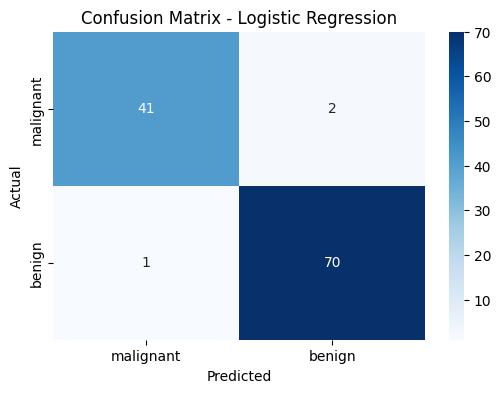

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


##Task 8: Interpret Coefficients
Display the coefficients of the trained model.


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort for interpretation
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

                    Feature  Coefficient
15        compactness error     0.682491
19  fractal dimension error     0.616230
5          mean compactness     0.540164
18           symmetry error     0.500425
8             mean symmetry     0.236119
11            texture error     0.188877
16          concavity error     0.175275
9    mean fractal dimension     0.075921
25        worst compactness     0.016110
4           mean smoothness    -0.071667
29  worst fractal dimension    -0.157414
17     concave points error    -0.311300
14         smoothness error    -0.313307
1              mean texture    -0.387326
2            mean perimeter    -0.393432
0               mean radius    -0.431904
3                 mean area    -0.465210
24         worst smoothness    -0.544170
22          worst perimeter    -0.589453
12          perimeter error    -0.610583
27     worst concave points    -0.778217
6            mean concavity    -0.801458
23               worst area    -0.841846
20             w

###Questions:
1. Which feature has the largest positive coefficient?

In [ ]:
coef_df.iloc[0]

,15
Feature,compactness error
Coefficient,0.682491


###2. which feature has the largest negative coefficient ?

In [ ]:
coef_df.iloc[-1]

,21
Feature,worst texture
Coefficient,-1.350606


3. What does the sign of a coefficient indicate ?

Positive coefficient (+)
→ As feature value increases → probability of class 1 increases
Negative coefficient (−)
→ As feature value increases → probability of class 1 decreases

##Part B: Support Vector Classification(SVC)

### Dataset Use the Iris Dataset

###Task1: Load the Dataset

In [ ]:

from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
x = iris.data
y = iris.target

###Task 2 : Exploratory Analysis: Determine
###1.Number of classes
###2.Number of features
###3.Class labels

In [ ]:
# Number of samples
num_samples = x.shape[0]

# Number of features
num_features = x.shape[1]

# Number of classes
num_classes = len(iris.target_names)

# Class labels
class_labels = iris.target_names

print("Number of samples:", num_samples)
print("Number of features:", num_features)
print("Number of classes:", num_classes)
print("Class labels:", class_labels)

Number of samples: 150
Number of features: 4
Number of classes: 3
Class labels: ['setosa' 'versicolor' 'virginica']


##Task3:Train-Test Split

In [ ]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# Display shapes
print("Training set shape (x_train):", x_train.shape)
print("Training labels shape (y_train):", y_train.shape)
print("Testing set shape (x_test):", x_test.shape)
print("Testing labels shape (y_test):", y_test.shape)

Training set shape (x_train): (105, 4)
Training labels shape (y_train): (105,)
Testing set shape (x_test): (45, 4)
Testing labels shape (y_test): (45,)


##Task4:Standardize Features

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)   # Fit on training data
x_test_scaled = scaler.transform(x_test)         # Transform test data

# Display shapes
print("Training set shape:", x_train_scaled.shape)
print("Testing set shape:", x_test_scaled.shape)

# Show first 5 rows of standardized training data
print("First five rows of standardized training data:")
print(x_train_scaled[:5])

Training set shape: (105, 4)
Testing set shape: (45, 4)
First five rows of standardized training data:
[[-0.4134164  -1.46200287 -0.09951105 -0.32339776]
 [ 0.55122187 -0.50256349  0.71770262  0.35303182]
 [ 0.67180165  0.21701605  0.95119225  0.75888956]
 [ 0.91296121 -0.02284379  0.30909579  0.2177459 ]
 [ 1.63643991  1.41631528  1.30142668  1.70589097]]


##Task5: Train Linear SVM

In [ ]:
from sklearn.svm import SVC
# Train Linear SVM
svc_linear = SVC(kernel='linear')
svc_linear.fit(x_train_scaled, y_train)

# Evaluate model
train_score = svc_linear.score(x_train_scaled, y_train)
test_score = svc_linear.score(x_test_scaled, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.9714285714285714
Testing Accuracy: 0.9777777777777777


##Task6:Evaluate the linear SVM

Accuracy: 0.9777777777777777
Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



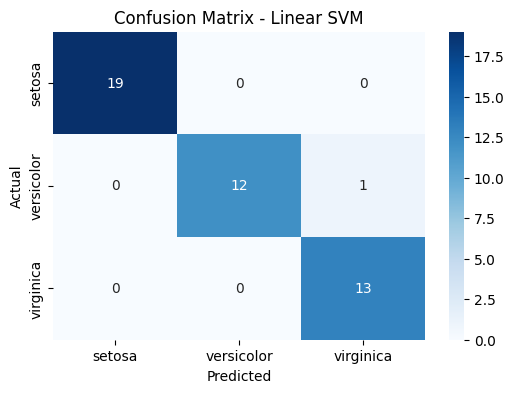

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions on test set
y_pred = svc_linear.predict(x_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Classification Report:\n", report)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

##Task7: Train RBF kernel SVM

In [ ]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(x_train_scaled, y_train)

y_pred_rbf = svc_rbf.predict(x_test_scaled)

print("RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf, target_names=iris.target_names))

RBF Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



##Task8: Compare Kernel

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

accuracy_linear = accuracy_score(y_test, y_pred)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

comparison = pd.DataFrame({
    'Kernel': ['Linear', 'RBF'],
    'Accuracy': [accuracy_linear, accuracy_rbf]
})

print(comparison)

   Kernel  Accuracy
0  Linear  0.977778
1     RBF  1.000000


##Task9: Hyperparamater Tuning

In [ ]:

# Hyperparameter values for C
C_values = [0.1, 1, 10, 100]
results = []

# Train and evaluate for each C
for C in C_values:
    svc_rbf = SVC(kernel='rbf', C=C)
    svc_rbf.fit(x_train_scaled, y_train)
    acc = accuracy_score(y_test, svc_rbf.predict(x_test_scaled))
    results.append({"C": C, "Accuracy": acc})

# Create comparison table
results_df = pd.DataFrame(results)
print(results_df)

       C  Accuracy
0    0.1  0.933333
1    1.0  1.000000
2   10.0  0.977778
3  100.0  0.977778


#PartC: Support Vector Regression(SVR)

In [ ]:

from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target

# Display shapes
print("Shape of x:", x.shape)   # Features
print("Shape of y:", y.shape)   # Target

# Show feature names
print("Feature names:", housing.feature_names)

# Show first five rows
print("First five rows of x:")
print(x[:5])
print("First five target values:")
print(y[:5])


Shape of x: (20640, 8)
Shape of y: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
First five rows of x:
[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]
First five target values:
[4.526 3.585 3.521 3.413 3.422]


##Task1: Load Dataset

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target

# Number of observations (rows)
num_observations = x.shape[0]

# Number of features (columns)
num_features = x.shape[1]

# Target description
target_description = "Median house value (in 100,000s of dollars) for California districts."

print("Number of observations:", num_observations)
print("Number of features:", num_features)
print("Description of target variable:", target_description)



Number of observations: 20640
Number of features: 8
Description of target variable: Median house value (in 100,000s of dollars) for California districts.


##Task2: Split Dataset

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Display shapes
print("Training set shape (x_train):", x_train.shape)
print("Training labels shape (y_train):", y_train.shape)
print("Testing set shape (x_test):", x_test.shape)
print("Testing labels shape (y_test):", y_test.shape)

Training set shape (x_train): (16512, 8)
Training labels shape (y_train): (16512,)
Testing set shape (x_test): (4128, 8)
Testing labels shape (y_test): (4128,)


##Task3: Standardize Features

In [ ]:
from sklearn.preprocessing import StandardScaler
# Apply StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)   # Fit on training data
x_test_scaled = scaler.transform(x_test)         # Transform test data

# Display shapes
print("Training set shape:", x_train_scaled.shape)
print("Testing set shape:", x_test_scaled.shape)

# Show first 5 rows of standardized training data
print("First five rows of standardized training data:")
print(x_train_scaled[:5])


Training set shape: (16512, 8)
Testing set shape: (4128, 8)
First five rows of standardized training data:
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


##Task4:Train linear SVR

In [ ]:
from sklearn.svm import SVR
# Train Linear SVR
svr_linear = SVR(kernel='linear')
svr_linear.fit(x_train_scaled, y_train)



SVR(kernel='linear')

##Task5: Predict House Prices

In [ ]:
# Generate predictions for the test set
y_pred = svr_linear.predict(x_test_scaled)

# Display first 10 predictions vs actual values
print("First 10 Predictions:", y_pred[:10])
print("First 10 Actual Values:", y_test[:10])

First 10 Predictions: [0.57328287 1.61361203 2.63246436 2.71669389 2.39888887 1.9803795
 2.48407358 1.95114536 2.78481939 3.82161628]
First 10 Actual Values: [0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


##Task6: Evaluate Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Predictions
y_pred = svr_linear.predict(x_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5119686230334923
Mean Squared Error (MSE): 0.5792224848666966
Root Mean Squared Error (RMSE): 0.7610666757037103
R² Score: 0.5579834277049536


##Task7: train RBF SVR

In [ ]:
# Train RBF SVR
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(x_train_scaled, y_train)

# Predictions
y_pred_rbf = svr_rbf.predict(x_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_rbf)
mse = mean_squared_error(y_test, y_pred_rbf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rbf)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.39859828301457567
Mean Squared Error (MSE): 0.3570026426754463
Root Mean Squared Error (RMSE): 0.5974969813107396
R² Score: 0.7275639524733044


##Task8: Compare Results

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target

# Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train Linear SVR
svr_linear = SVR(kernel='linear')
svr_linear.fit(x_train_scaled, y_train)
y_pred_linear = svr_linear.predict(x_test_scaled)

# Metrics for Linear SVR
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Train RBF SVR
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(x_train_scaled, y_train)
y_pred_rbf = svr_rbf.predict(x_test_scaled)

# Metrics for RBF SVR
mae_rbf = mean_absolute_error(y_test, y_pred_rbf)
rmse_rbf = np.sqrt(mean_squared_error(y_test, y_pred_rbf))
r2_rbf = r2_score(y_test, y_pred_rbf)

# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear SVR", "RBF SVR"],
    "MAE": [mae_linear, mae_rbf],
    "RMSE": [rmse_linear, rmse_rbf],
    "R²": [r2_linear, r2_rbf]
})

print(results)


        Model       MAE      RMSE        R²
0  Linear SVR  0.511969  0.761067  0.557983
1     RBF SVR  0.398598  0.597497  0.727564


##Task9: Effect of epsilon

In [ ]:

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np

# Load dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target

# Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Epsilon values to test
epsilon_values = [0.01, 0.1, 0.5, 1]
results = []

# Train and evaluate SVR for each epsilon
for eps in epsilon_values:
    svr_rbf = SVR(kernel='rbf', epsilon=eps)
    svr_rbf.fit(x_train_scaled, y_train)
    y_pred = svr_rbf.predict(x_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({"ε": eps, "RMSE": rmse})

# Create comparison table
results_df = pd.DataFrame(results)
print(results_df)

      ε      RMSE
0  0.01  0.598171
1  0.10  0.597497
2  0.50  0.595447
3  1.00  0.669452
